# Ball Drop Example

This example couples a basic ball drop physics experiment with {{surmise}}'s emulators and calibrators to explore a simple yet non-trivial use of {{surmise}}.  In particular, we will perform calibrations using a data set of experimental height values measured in time with surrogate models of two different parameterized models of the general form $h(\invar; \psp)$, where $h$ is the height of the ball above the ground, $\invar$ represents the independent, or input, variables; $\psp$, a point in the model's parameter space.

In the interest of keeping this example concise and clear, the level of care taken to configure, execute, and evaluate the quality of the Bayesian calibration is intentionally overly-simplistic.

Note that we will use `scipy.stats` to work with different common distributions.  Therefore, we adopt that package's notation and definitions for those distributions.

In [1]:
# Remove this cell in rendering

# Generate random seed
# import secrets
# secrets.randbits(128)

In [2]:
import numpy as np
import scipy.stats as sps

import surmise


RNG = np.random.default_rng(39761829560096686505152613678763426794)

EMULATOR_METHOD     = "PCGP"
N_EMU_THETA_SAMPLES = 50
CALIBRATION_METHOD  = "directbayes"
CALIBRATION_ARGS = {
    "sampler":     "metropolis_hastings",
    "theta0":      None,      # Set individually for each model
    "numsamp":     -1,        # Set individually for each model
    "burnSamples": -1,        # Set individually for each model
    "stepType":    "normal",
    "stepParam":   None,      # Set individually for each model
    "verbose":     True
}

In [3]:
# Remove this cell in rendering

import json

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as mfig
import seaborn as sns

from MplCalibrationSummary import MplCalibrationSummary

from IPython.display import display, Math

with open("MatplotlibEsthetics.json", "r") as fptr:
    esthetics = json.load(fptr)

plt.style.use(esthetics["style"])
FONTSIZE      = esthetics["fontsize"]
TICK_FONTSIZE = esthetics["tick_fontsize"]
MARKERSIZE    = esthetics["markersize"]
LINEWIDTH     = esthetics["linewidth"]

## Experimental Setup

A physicist has an experimental setup that will drop a ball from a given height and subsequently measure the height of the ball above the floor at different times.  The experiment is run from two different initial heights to gather the full data set for our calibrations.

In [4]:
H_0_LO = 35.0  # meters
H_0_HI = 50.0  # meters

While this example is contrived, the intent of using two different initial heights is to force the use of the slightly more complex independent variables
\begin{equation*}
\invar = (h_0, t),
\end{equation*}
which are the initial height of the experiment being measured and the time at which a position measurement is made for that experiment.

In [5]:
X_NAMES = ["h_0_m", "t_s"]
H_0_IDX, T_IDX = (0, 1)

The experimenter believes that the measurement error is the same regardless of the inital height and the height at which measurements were made.

In [6]:
H_VARIANCE = 4.0  # m^2

Rather than perform the actual experiments, we generate synthetic data, which is stored in the `DATASET` variable, using a model that we believe to be a good representation of the real world and higher-fidelity than the two models that we will use for calibration.  This model uses the well-known gravitational constant for objects close to the surface of the Earth and a terminal velocity.

In [7]:
G_STAR          = 9.81   # m/s^2
V_TERMINAL_STAR = 20.0   # m/s

Note that we do **not** add our own additive measurement noise to the synthetic data despite our assumed non-zero measurement error.  Thus, the source of error can be thought of as model specification error, {{ie}}, the model is inherently inadequate in representing the synthetic data.

In [8]:
# Remove this cell in rendering

def balldroptrue(x):
    h_0 = x[:, H_0_IDX]
    t   = x[:, T_IDX]
    assert all(h_0 > 0.0)
    assert all(t >= 0.0)

    def logcosh(t):
        # prevent crashing
        s = np.sign(t) * t
        p = np.exp(-2.0 * s)
        return s + np.log1p(p) - np.log(2.0)
    h = h_0 - (V_TERMINAL_STAR ** 2) / G_STAR * logcosh(G_STAR * t / V_TERMINAL_STAR)
    return h

T_SINGLE = np.arange(0.1, 3.81, 0.1)  # seconds
X_DATA = np.full([2 * len(T_SINGLE), 2], np.nan, float)
X_DATA[:, H_0_IDX] = np.concatenate(
    (H_0_LO * np.ones(len(T_SINGLE)), H_0_HI * np.ones(len(T_SINGLE)))
)
X_DATA[:, T_IDX] = np.concatenate((T_SINGLE, T_SINGLE))

# Only retain data where ball is at or above the ground
h_data = balldroptrue(X_DATA)
idx_nonneg = np.where(h_data >= 0.0)
DATASET = {"x": X_DATA[idx_nonneg],
           "y": h_data[idx_nonneg]}
DATASET["yvar"] = H_VARIANCE * np.ones(len(DATASET["y"]))

A tabular snippet of the dataset helps visualize the data set's structure

In [9]:
# Remove this cell's input in rendering

indices = pd.MultiIndex.from_arrays(
    DATASET["x"].T, names=X_NAMES
)
df = pd.DataFrame(data=DATASET["y"], columns=["height_m"], index=indices)
with pd.option_context('display.max_rows', 10):
    display(df)

height_m
h_0_m t_s           
35.0  0.1  34.950970
      0.2  34.804114
      0.3  34.560134
      0.4  34.220184
      0.5  33.785849
...              ...
50.0  3.4   8.836529
      3.5   6.967717
      3.6   5.087012
      3.7   3.195462
      3.8   1.294028

[68 rows x 1 columns]

and the contents of the single data set are graphed.

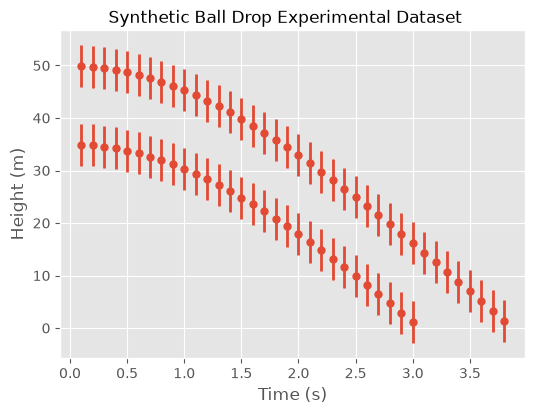

In [10]:
# Remove this cell's input in rendering

fig = plt.figure(1, figsize=(6, 4))
fig.suptitle("Synthetic Ball Drop Experimental Dataset", fontsize=FONTSIZE)
fig.subplots_adjust(top=0.93)

subp = fig.add_subplot(111)
subp.errorbar(DATASET["x"][:, T_IDX], DATASET["y"], yerr=DATASET["yvar"],
              marker='o', markersize=MARKERSIZE,
              linewidth=0.0, elinewidth=LINEWIDTH)
subp.set_xlabel("Time (s)", fontsize=FONTSIZE)
subp.set_ylabel("Height (m)", fontsize=FONTSIZE)
subp.tick_params(axis="both", labelsize=TICK_FONTSIZE)
subp.grid(True)

## Low-fidelity Model
Physicists typically assume that acceleration due to gravity near the surface of the Earth, $g$, is constant.  Based on this and assuming that there are no other forces, such as air resistance, acting on the ball, a simple model is
\begin{equation*}
h_{vac}(h_0, t; g) = h_0 - \frac{1}{2}g t^2
\end{equation*}
where, contrary to typical notation, $h_0 > 0$ is an independent variable and $\psp = g > 0$ is the single unknown parameter for this model.

In particular, this model would be a high-fidelity model if the experiment had been performed in a vacuum such as space.  However, we will see that it is indeed a low-fidelity model when fit to data measured in a lab.

In [11]:
def balldropmodel_vacuum(x, theta):
    assert all(theta > 0.0)
    h_0 = x[:, H_0_IDX]
    t   = x[:, T_IDX]
    assert all(h_0 > 0.0)
    assert all(t >= 0.0)

    f = np.zeros((theta.shape[0], len(t)))
    for k in range(f.shape[0]):
        g = theta[k, 0]
        f[k, :] = h_0 - 0.5 * g * (t ** 2)
    return f.T

Since this is a Bayesian calibration, we assume that $g$ is a random variable and specify a prior distribution for it.  To guide the choice of this prior distribution, we know that
* $g > 0$ and
* $g$ is commonly taken to be approximately 10 $m/s^2$.

A reasonable choice is, therefore,
\begin{equation*}
g \sim \Gamma(\alpha=5, \beta=1/2)
\end{equation*}
since its mean is 10 and much of the probability is bunched around this with a slight skew toward smaller accelerations.

In [12]:
class prior_g_vacuum:
    ALPHA = 5.0
    BETA  = 0.5

    def lpdf(theta):
        assert all(theta > 0.0)
        values = sps.gamma.logpdf(theta,
                                  a=prior_g_vacuum.ALPHA,
                                  loc=0.0,
                                  scale=1.0 / prior_g_vacuum.BETA)
        return values.reshape((len(theta), 1))

    def rnd(n):
        samples = sps.gamma.rvs(a=prior_g_vacuum.ALPHA,
                                loc=0.0,
                                scale=1.0 / prior_g_vacuum.BETA,
                                size=n,
                                random_state=RNG)
        return np.reshape(samples, (-1,1))

prior_g_mean, prior_g_var = sps.gamma.stats(
    a=prior_g_vacuum.ALPHA,
    loc=0.0,
    scale=1.0 / prior_g_vacuum.BETA,
    moments="mv"
)

In [13]:
# Remove this cell in rendering

assert prior_g_vacuum.ALPHA > 0.0
assert prior_g_vacuum.BETA > 0.0

# Expected test values determined using results in
# https://en.wikipedia.org/wiki/Gamma_distribution
# Where wiki's lambda is scipy.stat's beta

assert prior_g_mean == 10.0  # alpha/beta
assert prior_g_var == 20.0   # alpha/beta^2

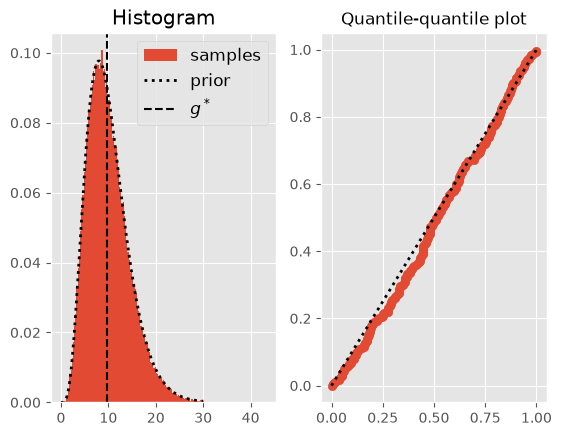

In [14]:
# Remove this cell in rendering

# This is a very quick, dirty, rough manual check of prior_g_vacuum

# TODO: Include automated test that confirms that histogram is good estimation of distribution?

g_data = np.linspace(1.0e-15, 30.0, 1000)
pdf_data = np.exp(prior_g_vacuum.lpdf(g_data))

unif_zero_one = np.linspace(0, 1, 1000)

fig = plt.figure(2)

subp = fig.add_subplot(121)
subp.hist(prior_g_vacuum.rnd(100000), bins="auto", density=True, label="samples")
subp.plot(g_data, pdf_data, 'k:', linewidth=LINEWIDTH, label="prior")
subp.axvline(G_STAR, color="black", linestyle="--", label=r"$g^*$")
subp.legend(loc="best", fontsize=FONTSIZE)
subp.set_title('Histogram')
subp.grid(True)
subp2 = fig.add_subplot(122)
subp2.scatter(sps.gamma.cdf(sorted(prior_g_vacuum.rnd(250)), 
                         a=prior_g_vacuum.ALPHA,
                         loc=0.0,
                         scale=1.0 / prior_g_vacuum.BETA), 
              np.arange(0, 1, 1/250),
              marker='o'
             )
subp2.set_title('Quantile-quantile plot', fontsize=FONTSIZE)
subp2.plot(unif_zero_one, unif_zero_one, 'k:', linewidth=LINEWIDTH)

We emulate the low-fidelity model and test the emulator at predetermined times

In [15]:
t_emulator_lo = np.arange(0.0, 3.5, 0.1)
t_emulator_hi = np.arange(0.0, 4.3, 0.1)

x_emulator_vacuum = np.full([len(t_emulator_lo) + len(t_emulator_hi), 2], np.nan, float)
x_emulator_vacuum[:, T_IDX] = np.concatenate(
    (t_emulator_lo, t_emulator_hi)
)
x_emulator_vacuum[:, H_0_IDX] = np.concatenate(
    (H_0_LO * np.ones(len(t_emulator_lo)),
     H_0_HI * np.ones(len(t_emulator_hi)))
)

In [16]:
# Remove this cell's input in rendering

with pd.option_context('display.max_rows', 10):
    display(pd.DataFrame(data=x_emulator_vacuum, columns=X_NAMES))

,h_0_m,t_s
0,35.0,0.0
1,35.0,0.1
2,35.0,0.2
3,35.0,0.3
4,35.0,0.4
...,...,...
73,50.0,3.8
74,50.0,3.9
75,50.0,4.0
76,50.0,4.1


and using $g$ values sampled from our prior.

In [17]:
g_vacuum_train = prior_g_vacuum.rnd(N_EMU_THETA_SAMPLES)

f_vacuum_train = balldropmodel_vacuum(x_emulator_vacuum, g_vacuum_train)  

emu_vacuum = surmise.emulator(x=x_emulator_vacuum,
                              theta=g_vacuum_train,
                              f=f_vacuum_train,
                              method=EMULATOR_METHOD)

g_vacuum_test = prior_g_vacuum.rnd(N_EMU_THETA_SAMPLES)
f_vacuum_test = balldropmodel_vacuum(x_emulator_vacuum, g_vacuum_test)  

pred_vacuum = emu_vacuum.predict(x=x_emulator_vacuum, theta=g_vacuum_test)
pred_vacumm_m, pred_vacuum_var = pred_vacuum.mean(), pred_vacuum.var()

display(Math(r'R^2 = {:.3f}'.format(1 - np.sum(np.square(pred_vacumm_m - f_vacuum_test))/np.sum(np.square(f_vacuum_test.T - np.mean(f_vacuum_test, axis = 1))))))
print('Root Mean Squared Error = {:.3f}'.format(np.sqrt(np.mean(np.square(pred_vacumm_m - f_vacuum_test)))))

<IPython.core.display.Math object>

Root Mean Squared Error = 0.143


In [18]:
g_0 = prior_g_mean

print()
print("Prior distribution characterization")
print("-" * 80)
print(f"Mean g = {prior_g_mean} m/s^2")
print(f"Std  g = {np.sqrt(prior_g_var)} m/s^2")
print()
print("Calibration starting point")
print("-" * 80)
print(f"g = {g_0} m/s^2")
print()

args = CALIBRATION_ARGS.copy()
args["theta0"]      = np.array([[g_0]])
args["numsamp"]     = 1000
args["burnSamples"] = 1000
args["stepParam"]   = np.array([0.2])

cal_vacuum = surmise.calibrator(
    emu=emu_vacuum,
    x=DATASET["x"], y=DATASET["y"], yvar=DATASET["yvar"],
    thetaprior=prior_g_vacuum, 
    method=CALIBRATION_METHOD, args=args
)


Prior distribution characterization
--------------------------------------------------------------------------------
Mean g = 10.0 m/s^2
Std  g = 4.47213595499958 m/s^2

Calibration starting point
--------------------------------------------------------------------------------
g = 10.0 m/s^2

Final Acceptance Rate:  0.447


We have access to the estimate of the posterior distribution and can use it to access summary statistics

In [19]:
posterior_mean = cal_vacuum.theta.mean()
posterior_std = np.sqrt(cal_vacuum.theta.var())

print()
print(f"g posterior mean = {posterior_mean[0]}")
print(f"g posterior std  = {posterior_std[0]}")


g posterior mean = 7.489307644145341
g posterior std  = 0.07822030011492864


In [20]:
# Remove this cell in rendering

# The checks in this cell are rough, empirically-determined checks of
# statistical quantities.  Therefore, they might fail on occasion.  If they
# do and the tests are "just" failing, consider rerunning or using a
# different random seed.

# TODO: It would be nice to be able to access the final acceptance rate and 
# add a check that it is an acceptable value.

# Rounded posterior mean from one single execution of notebook
expected = 7.465

# Check that std is not ridiculously large, which could decrease utility
# of the next check.
#
# Limits determined empirically by running calibration many times.
if (posterior_std[0] < 0.075) or (posterior_std[0] > 0.095):
    raise ValueError(posterior_std[0])

if np.fabs(expected - posterior_mean[0]) > 3.0 * posterior_std[0]:
    print(posterior_std[0])
    raise RuntimeError(np.fabs(expected - posterior_mean[0]))

Therefore, the Bayesian analysis resulted in a posterior that is much narrower than the prior and shifted both from the mean and mode of the prior as well from the true value of $g$, which might be expected since we have used the low-fidelity model.

We can also access the samples used by the calibration process
* in the order in which they were sampled and
* with a randomized ordering

for visualizing some aspects of the calibration process.

In [21]:
samples_MC_vacuum         = cal_vacuum.info["thetarnd"]
samples_randomized_vacuum = cal_vacuum.theta.rnd(args["numsamp"])

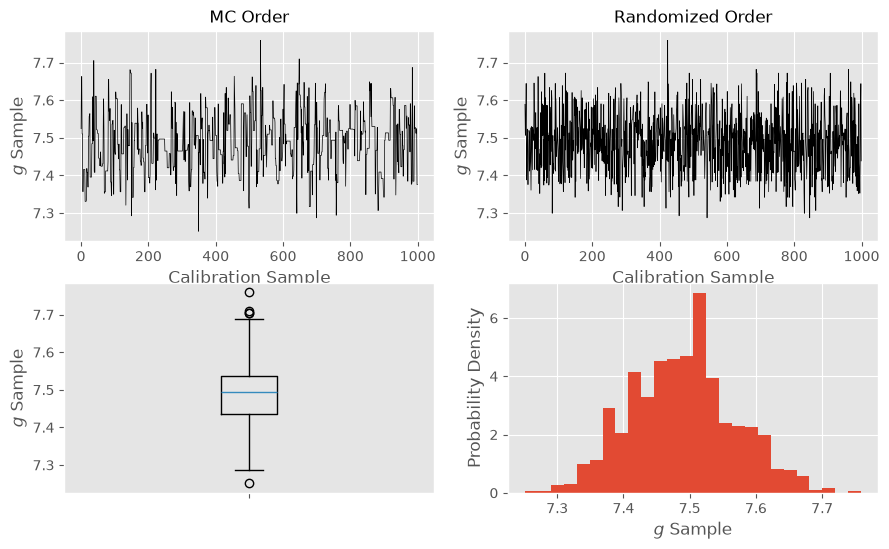

In [22]:
# Remove this cell's input in rendering

subp = mfig.SubplotParams(left=0.12, right=0.98,
                          top=0.91, bottom=0.06,
                          wspace=0.2, hspace=0.3)
fig = plt.figure(num=3, FigureClass=MplCalibrationSummary,
                 figsize=(10.5, 6), subplotpars=subp)
fig.fontsize = FONTSIZE
fig.tick_fontsize = TICK_FONTSIZE
fig.linewidth = 0.25 * LINEWIDTH
fig.draw_figure(r"$g$", samples_MC_vacuum, samples_randomized_vacuum, bins="auto")

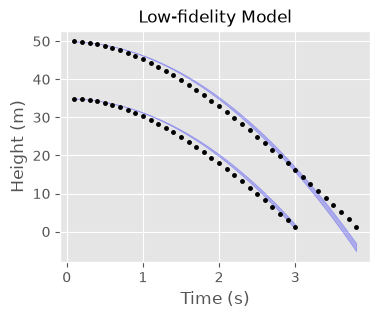

In [23]:
cal_vacuum_post = cal_vacuum.predict(DATASET["x"])
rndm_vacuum_m = cal_vacuum_post.rnd(s = 1000)

fig = plt.figure(4, figsize=(4, 3))

subp = fig.add_subplot(111)
subp.set_title("Low-fidelity Model", fontsize=FONTSIZE)
for k in (H_0_LO, H_0_HI):
    inds = np.where(DATASET["x"][:, H_0_IDX] == k)[0]
    upper = np.percentile(rndm_vacuum_m[:, inds], 97.5, axis=0)
    lower = np.percentile(rndm_vacuum_m[:, inds],  2.5, axis=0)
    subp.fill_between(DATASET["x"][inds, T_IDX], lower, upper, color = 'blue', alpha=0.25)
    subp.plot(DATASET["x"][inds, T_IDX], DATASET["y"][inds], 'k.', markersize = 5)
subp.set_xlabel("Time (s)", fontsize=FONTSIZE)
subp.set_ylabel("Height (m)", fontsize=FONTSIZE)
subp.tick_params(axis="both", labelsize=TICK_FONTSIZE)

While the fit to the low initial ball height expertimental data is not so bad, the disagreement between model and data degrades for large times for the higher initial ball height data.  This further suggests that the low-fidelity model is poor.

## High-fidelity Model
To better represent the physics of this laboratory experiment, the physicist specifies a second model that attempts to account for the effect of air resistance on the ball by assuming that after some time $t_{ter} > 0$ the ball will move linearly with terminal speed $v_{ter} > 0$ due to the balancing of the forces of air resistance and gravity on the ball or
\begin{equation*}
h_{air}(h_0, t; c_{ter}, v_{ter}) = h_0 - c_{ter} - v_{ter}(t - t_{ter}),
\end{equation*}
where
* $h_0 > 0$ is still the initial height of the ball above the ground at time $t=0$ and
* $c_{ter} > 0$ is the distance traveled by the ball in time $t_{ter}$.

The unknown parameters for this problem are $\psp = (c_{ter}, v_{ter})$.

In [24]:
C_TER_IDX, V_TER_IDX = (0, 1)
THETA_NAMES = ["$c_{ter}$", r"$v_{ter}$"]

While an improvement, this model is still flawed.  For example, the model should only be used for $t \ge t_{ter}$.

In [25]:
T_TERMINAL = 2.0  # seconds

def balldropmodel_air(x, theta):
    h_0 = x[:, H_0_IDX]
    t   = x[:, T_IDX]
    assert all(h_0 > 0.0)
    assert all(t >= T_TERMINAL)
    assert all(theta.flatten() > 0.0)
    c_ter = theta[:, C_TER_IDX]
    v_ter = theta[:, V_TER_IDX]

    f = np.zeros((theta.shape[0], x.shape[0]))
    for k in range(f.shape[0]):
        f[k, :] = h_0 - c_ter[k] - v_ter[k] * (t - T_TERMINAL)
    return f.T

Since this is a Bayesian treatment, we assume that $c_{ter}, v_{ter}$ are random variables and specify a joint prior distribution for them.  If the relationship among the unknown parameters is known, one may suggest a prior distribution that encodes correlation.  Otherwise, an independence assumption may be assumed, as done below.

To determine this, we know that $v_{ter}$ must be positive.  Since the low-fidelity model has only gravity acting on the ball and the high-fidelity model has the additional force of air resistance countering gravity, we hope that the low-fidelity model predicts a larger displacement than the high-fidelity model at each time.  Therefore, we suspect that
\begin{equation*}
0 < c_{ter} \le h_0 - h_{vac}(h_0, t_{ter}; \E[g]).
\end{equation*}
We assume that the two random variables are independent and specify the (hopefully) reasonable marginal prior distributions

* $v_{ter} \sim \Gamma(\alpha=5, \beta=1/3)$ and

* $c_{ter} \sim \mathcal{U}_{[0, h_0 - h_{vac}(h_0, t_{ter}; \E[g])]}$.

In [26]:
x_ter = np.full([1, 2], np.nan, float)
x_ter[0, H_0_IDX] = H_0_HI
x_ter[0, T_IDX] = T_TERMINAL

theta = np.array([[prior_g_mean]])

max_displacement_t_ter = H_0_HI - balldropmodel_vacuum(x_ter, theta)[0][0]

class prior_theta_air:
    C_LO = 0.0
    C_HI = max_displacement_t_ter

    V_ALPHA = 5.0
    V_BETA  = 1.0 / 3.0

    def lpdf(theta):
        assert all(theta.flatten() > 0.0)
        c_values = sps.uniform.logpdf(theta[:, C_TER_IDX],
                                      loc=prior_theta_air.C_LO,
                                      scale=prior_theta_air.C_HI - prior_theta_air.C_LO)
        v_values = sps.gamma.logpdf(theta[:, V_TER_IDX],
                                    a=prior_theta_air.V_ALPHA,
                                    loc=0.0,
                                    scale=1.0 / prior_theta_air.V_BETA)
        return (c_values + v_values).reshape((len(theta), 1))

    def rnd(n):
        samples = np.full([n, 2], np.nan, float)
        samples[:, C_TER_IDX] = sps.uniform.rvs(
            loc=prior_theta_air.C_LO,
            scale=prior_theta_air.C_HI - prior_theta_air.C_LO,
            size=n,
            random_state=RNG
        )
        samples[:, V_TER_IDX] = sps.gamma.rvs(
            a=prior_theta_air.V_ALPHA,
            loc=0.0,
            scale=1.0 / prior_theta_air.V_BETA,
            size=n,
            random_state=RNG
        )    
        return samples

prior_c_ter_mean = 0.5 * (prior_theta_air.C_LO + prior_theta_air.C_HI)
prior_c_ter_var  = (prior_theta_air.C_HI - prior_theta_air.C_LO)**2 / 12.0

prior_v_ter_mean = prior_theta_air.V_ALPHA / prior_theta_air.V_BETA
prior_v_ter_var  = prior_theta_air.V_ALPHA / prior_theta_air.V_BETA**2

In [27]:
# Remove this cell in rendering

assert prior_theta_air.C_HI > prior_theta_air.C_LO
assert prior_theta_air.V_ALPHA > 0.0
assert prior_theta_air.V_BETA > 0.0

# Expected test values determined using results in
# https://en.wikipedia.org/wiki/Gamma_distribution
# Where wiki's lambda is scipy.stat's beta

assert prior_v_ter_mean == 15.0
assert prior_v_ter_var == 45.0

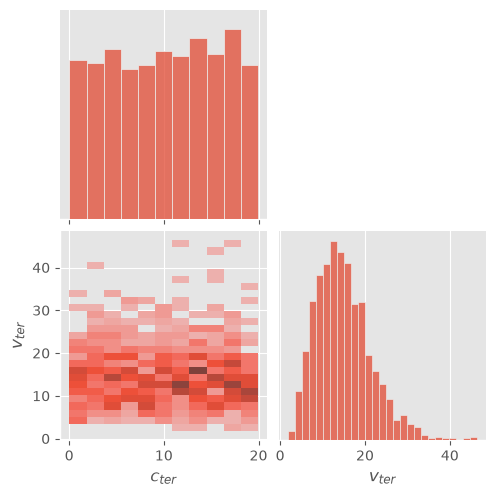

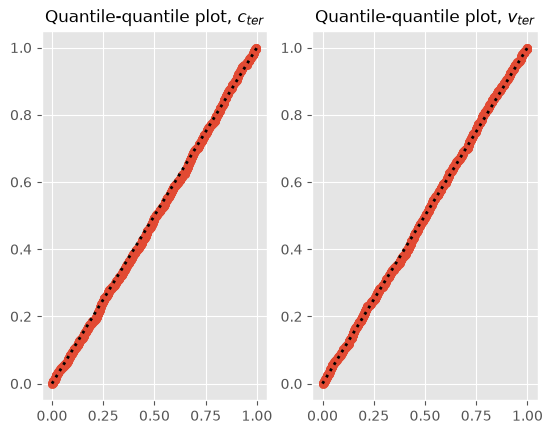

In [28]:
# Remove this cell in rendering

# This is a very quick, dirty, rough manual check of prior_theta_air

# Marginal Q-Q plot should be a straight line when the prior is correctly describing the samples

# TODO: Include automated test that confirms that histogram is good estimation of distribution?

nsamp = 1000
samples_prior_air = prior_theta_air.rnd(nsamp)

_ = sns.pairplot(pd.DataFrame(samples_prior_air, columns=THETA_NAMES),
                 kind="hist",             
                 corner=True)

fig = plt.figure(num=5)
subp = fig.add_subplot(121)
subp.scatter(sps.uniform.cdf(sorted(samples_prior_air[:, C_TER_IDX]),
                             loc=prior_theta_air.C_LO,
                             scale=prior_theta_air.C_HI - prior_theta_air.C_LO),
              np.arange(0, 1, 1/nsamp),
              marker='o'
             )
subp.set_title('Quantile-quantile plot, {:s}'.format(THETA_NAMES[C_TER_IDX]), fontsize=FONTSIZE)
subp.plot(unif_zero_one, unif_zero_one, 'k:', linewidth=LINEWIDTH)

subp = fig.add_subplot(122)
subp.scatter(sps.gamma.cdf(sorted(samples_prior_air[:, V_TER_IDX]), 
                         a=prior_theta_air.V_ALPHA,
                         loc=0.0,
                         scale=1.0 / prior_theta_air.V_BETA), 
              np.arange(0, 1, 1/nsamp),
              marker='o'
             )
subp.set_title('Quantile-quantile plot, {:s}'.format(THETA_NAMES[V_TER_IDX]), fontsize=FONTSIZE)
subp.plot(unif_zero_one, unif_zero_one, 'k:', linewidth=LINEWIDTH)

We emulate the high-fidelity model and test the emulator at predetermined times

In [29]:
t_emulator_lo = np.arange(T_TERMINAL, 3.5, 0.1)
t_emulator_hi = np.arange(T_TERMINAL, 4.3, 0.1)

x_emulator_air = np.full([len(t_emulator_lo) + len(t_emulator_hi), 2], np.nan, float)
x_emulator_air[:, T_IDX] = np.concatenate(
    (t_emulator_lo, t_emulator_hi)
)
x_emulator_air[:, H_0_IDX] = np.concatenate(
    (H_0_LO * np.ones(len(t_emulator_lo)),
     H_0_HI * np.ones(len(t_emulator_hi)))
)

In [30]:
# Remove this cell's input in rendering

with pd.option_context('display.max_rows', 10):
    display(pd.DataFrame(data=x_emulator_air, columns=X_NAMES))

,h_0_m,t_s
0,35.0,2.0
1,35.0,2.1
2,35.0,2.2
3,35.0,2.3
4,35.0,2.4
...,...,...
33,50.0,3.8
34,50.0,3.9
35,50.0,4.0
36,50.0,4.1


and using $c_{ter}, v_{ter}$ values sampled from our prior.

In [31]:
theta_air_train = prior_theta_air.rnd(N_EMU_THETA_SAMPLES)

f_air_train = balldropmodel_air(x_emulator_air, theta_air_train)  

emu_air = surmise.emulator(x=x_emulator_air,
                           theta=theta_air_train,
                           f=f_air_train,
                           method=EMULATOR_METHOD)

theta_air_test = prior_theta_air.rnd(N_EMU_THETA_SAMPLES)
f_air_test = balldropmodel_air(x_emulator_air, theta_air_test)  

pred_air = emu_air.predict(x=x_emulator_air, theta=theta_air_test)
pred_air_m, pred_air_var = pred_air.mean(), pred_air.var()

display(Math(r'R^2 = {:.3f}'.format(1 - np.sum(np.square(pred_air_m - f_air_test))/np.sum(np.square(f_air_test.T - np.mean(f_air_test, axis = 1))))))
print('Root Mean Squared Error = {:.3f}'.format(np.sqrt(np.mean(np.square(pred_air_m - f_air_test)))))

<IPython.core.display.Math object>

Root Mean Squared Error = 0.008


Since this model is valid only once the ball has acheived terminal velocity, we will only calibrate the model using data acquired with $t \ge t_{ter}$.  After the calibration is done, we should check if the calibration results are at least consistent with the modeler's choice of $t_{ter}$.

In [32]:
indices = np.where(DATASET["x"][:, T_IDX] >= T_TERMINAL)

theta_0 = np.full(2, np.nan, float)
step_size = theta_0.copy()

theta_0[C_TER_IDX] = prior_c_ter_mean
theta_0[V_TER_IDX] = prior_v_ter_mean

step_size[C_TER_IDX] = 0.25
step_size[V_TER_IDX] = 1.0

print()
print("Marginal prior distribution characterizations")
print("-" * 80)
print(f"Mean c_ter = {prior_c_ter_mean} m")
print(f"Std  c_ter = {np.sqrt(prior_c_ter_var)} m")
print()
print(f"Mean v_ter = {prior_v_ter_mean} m/s")
print(f"Std  v_ter = {np.sqrt(prior_v_ter_var)} m/s")
print()
print("Calibration starting point")
print("-" * 80)
print(f"c_ter = {theta_0[C_TER_IDX]} m")
print(f"v_ter = {theta_0[V_TER_IDX]} m/s")
print()

args = CALIBRATION_ARGS.copy()
args["theta0"]      = theta_0.reshape(1, len(theta_0))
args["numsamp"]     = 10000
args["burnSamples"] = 1000
args["stepParam"]   = step_size

cal_air = surmise.calibrator(
    emu=emu_air,
    x=DATASET["x"][indices],
    y=DATASET["y"][indices],
    yvar=DATASET["yvar"][indices],
    thetaprior=prior_theta_air, 
    method=CALIBRATION_METHOD, args=args
)

# Access data for studying calibration as for low-fidelity model
posterior_mean_air = cal_air.theta.mean()
c_ter_posterior_mean = posterior_mean_air[C_TER_IDX]
v_ter_posterior_mean = posterior_mean_air[V_TER_IDX]
posterior_std_air = np.sqrt(cal_air.theta.var())
c_ter_posterior_std = posterior_std_air[C_TER_IDX]
v_ter_posterior_std = posterior_std_air[V_TER_IDX]

samples_MC_air         = cal_air.info["thetarnd"]
samples_randomized_air = cal_air.theta.rnd(args["numsamp"])


Marginal prior distribution characterizations
--------------------------------------------------------------------------------
Mean c_ter = 10.0 m
Std  c_ter = 5.773502691896258 m

Mean v_ter = 15.0 m/s
Std  v_ter = 6.708203932499369 m/s

Calibration starting point
--------------------------------------------------------------------------------
c_ter = 10.0 m
v_ter = 15.0 m/s

Final Acceptance Rate:  0.4042


In [33]:
# Remove this cell's input in rendering

# The checks in this cell are rough, empirically-determined checks of
# statistical quantities.  Therefore, they might fail on occasion.  If they
# do and the tests are "just" failing, consider rerunning or using a
# different random seed.

# TODO: It would be nice to be able to access the final acceptance rate and 
# add a check that it is an acceptable value.

print(f"c_ter posterior mean = {c_ter_posterior_mean}")
print(f"c_ter posterior std  = {c_ter_posterior_std}")
print()
print(f"v_ter posterior mean = {v_ter_posterior_mean}")
print(f"v_ter posterior std  = {v_ter_posterior_std}")
print()

# Check that std are not ridiculously large, which could decrease utility
# of the next checks.
#
# Limits determined empirically by running calibration many times.
if (c_ter_posterior_std < 0.55) or (c_ter_posterior_std > 0.85):
    raise RuntimeError(c_ter_posterior_std)
if (v_ter_posterior_std < 0.65) or (v_ter_posterior_std > 0.85):
    raise RuntimeError(v_ter_posterior_std)

# Rounded posterior mean from one single execution of notebook
expected = 16.540
if np.fabs(expected - c_ter_posterior_mean) > 3.0 * c_ter_posterior_std:
    print(c_ter_posterior_std)
    raise RuntimeError(np.fabs(expected - c_ter_posterior_mean))

# Rounded posterior mean from one single execution of notebook
expected = 17.513
if np.fabs(expected - v_ter_posterior_mean) > 3.0 * v_ter_posterior_std:
    print(v_ter_posterior_std)
    raise RuntimeError(np.fabs(expected - v_ter_posterior_mean))

# Sanity check posterior distribution against upper bound
if c_ter_posterior_mean + 4.0 * c_ter_posterior_std > max_displacement_t_ter:
    print(c_ter_posterior_mean)
    print(c_ter_posterior_std)
    raise RuntimeError(max_displacement_t_ter)

c_ter posterior mean = 16.55212178881513
c_ter posterior std  = 0.6146148730476914

v_ter posterior mean = 17.509976159431062
v_ter posterior std  = 0.681776179469436



The calibration has resulted in marginal posterior distributions that are narrower than for the marginal priors and that have each shifted a bit from the means of the marginal priors.

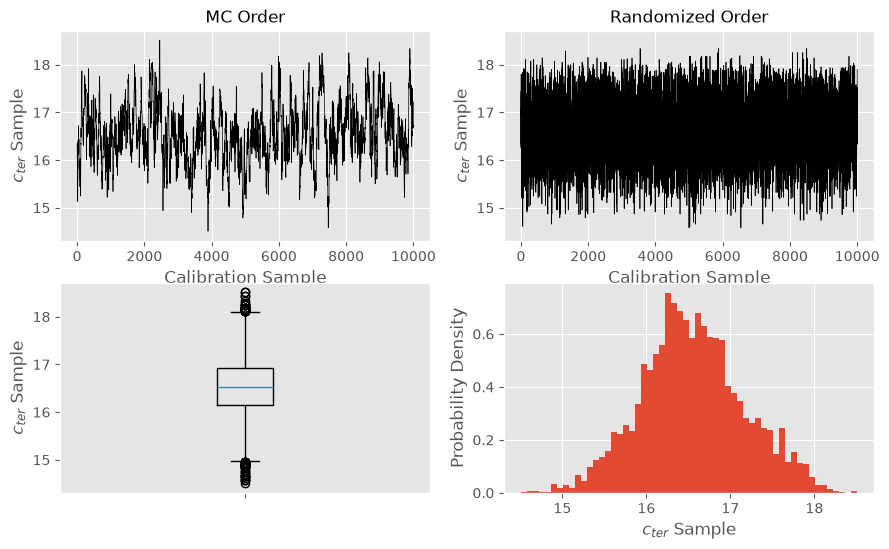

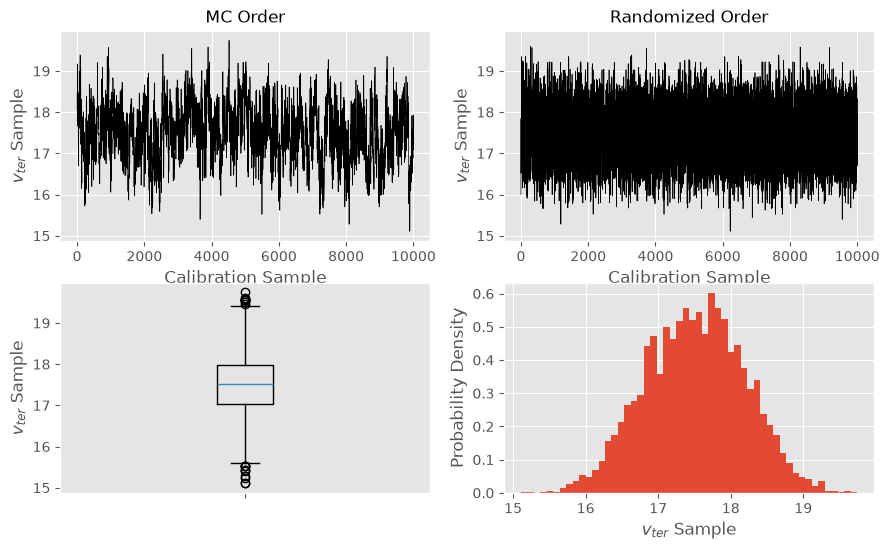

In [34]:
# Remove this cell's input in rendering

subp = mfig.SubplotParams(left=0.12, right=0.98,
                          top=0.91, bottom=0.06,
                          wspace=0.2, hspace=0.3)

for i, var in enumerate(THETA_NAMES):
    fig = plt.figure(num=6 + i, FigureClass=MplCalibrationSummary,
                     figsize=(10.5, 6), subplotpars=subp)
    fig.fontsize = FONTSIZE
    fig.tick_fontsize = TICK_FONTSIZE
    fig.linewidth = 0.25 * LINEWIDTH
    fig.draw_figure(var, samples_MC_air[:, i], samples_randomized_air[:, i], bins="auto")

Happily, the supports of the marginal posterior distributions are consistent with the lower and upper limits discussed when defining the prior distribution.  Note that the true value for the terminal velocity is in the upper tail of the marginal posterior distribution.  While this could be due to a insufficiency in our calibration procedure, it could also indicate that the high-fidelity model is still a poor model for physical reality.

The MC ordered sample plots indicate an anticorrelation between the two parameters, which is seen more clearly in the histogram of the joint posterior distribution in the corner plot.

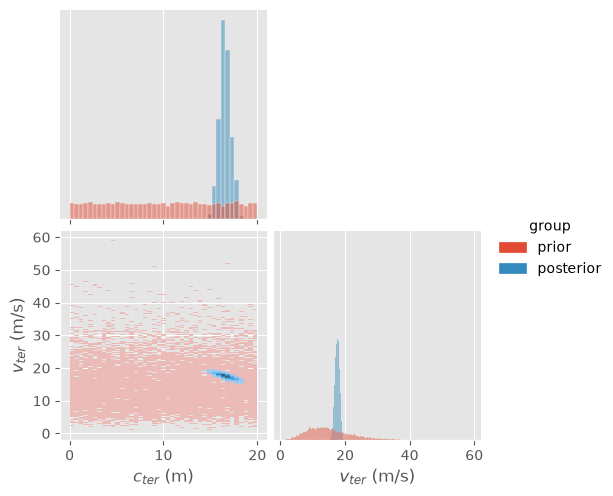

In [35]:
# Remove this cell's input in rendering
samples_prior_air = prior_theta_air.rnd(10000)

df_prior = pd.DataFrame({f"{THETA_NAMES[C_TER_IDX]} (m)":   samples_prior_air[:, C_TER_IDX],
                         f"{THETA_NAMES[V_TER_IDX]} (m/s)": samples_prior_air[:, V_TER_IDX]})
df_prior['group'] = 'prior'

df_posterior = pd.DataFrame({f"{THETA_NAMES[C_TER_IDX]} (m)":   samples_MC_air[:, C_TER_IDX],
                             f"{THETA_NAMES[V_TER_IDX]} (m/s)": samples_MC_air[:, V_TER_IDX]})
df_posterior['group'] = 'posterior'

df = pd.concat((df_prior, df_posterior))

_ = sns.pairplot(df, hue='group', kind='hist', corner=True)

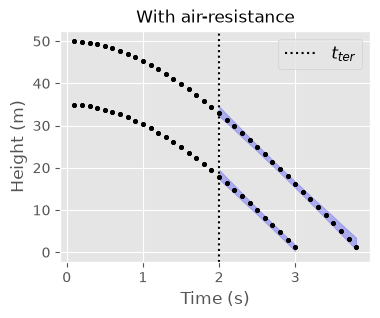

In [36]:
indices = np.where(DATASET["x"][:, T_IDX] >= T_TERMINAL)
dataset_x_ter = DATASET["x"][indices]

cal_air_post = cal_air.predict(dataset_x_ter)
rndm_air_m = cal_air_post.rnd(s = 1000)

fig = plt.figure(9, figsize=(4, 3))

subp = fig.add_subplot(111)
subp.set_title("With air-resistance", fontsize=FONTSIZE)

for k in (H_0_LO, H_0_HI):
    inds = np.where(np.squeeze(dataset_x_ter[:, H_0_IDX] == k))[0]
    upper = np.percentile(rndm_air_m[:, inds], 97.5, axis = 0)
    lower = np.percentile(rndm_air_m[:, inds], 2.5, axis = 0)
    subp.fill_between(dataset_x_ter[inds, T_IDX], lower, upper, color = 'blue', alpha=0.25)
    subp.plot(DATASET["x"][:, T_IDX], DATASET["y"], 'k.', markersize = 5)

subp.axvline(T_TERMINAL, color="black", linestyle=":", label=r"$t_{ter}$")
subp.set_xlabel("Time (s)", fontsize=FONTSIZE)
subp.set_ylabel("Height (m)", fontsize=FONTSIZE)
subp.tick_params(axis="both", labelsize=TICK_FONTSIZE)
_ = subp.legend(loc="best", fontsize=FONTSIZE)

For this higher-fidelity calibration, the posterior predictions for $t \ge t_{ter}$ are much better than the low-fidelity model predictions as expected.